### Import Necessary Libraries
In this section, we import all the required libraries for our analysis:
- `numpy` and `pandas` for data manipulation.
- `matplotlib.pyplot` and `seaborn` for data visualization.
- `sklearn` modules for model preparation, training, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression 


### Load and Explore the Dataset
We load the mobile price training dataset into a Pandas DataFrame, review its shape, columns, basic statistics, missing values, and duplicate records.

In [2]:
df = pd.read_csv(r'F:\HUAWEL_AI\GitHub\Data_CSV\mobile_price_train.csv')

print("Dataset shape:", df.shape)

print("\nDataFrame Columns")
print(df.columns)

print("\nColumn information:")
print(df.info())

print("\nMissing values (Null):")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

print("\nDuplicated:")
print(df.duplicated().sum())

Dataset shape: (2000, 21)

DataFrame Columns
Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc         

### Feature Selection based on Correlation
We calculate and visualize the correlation matrix of numerical features using a heatmap. This helps us identify which features strongly influence our target variable (`price_range`), allowing us to select only the most relevant predictors.

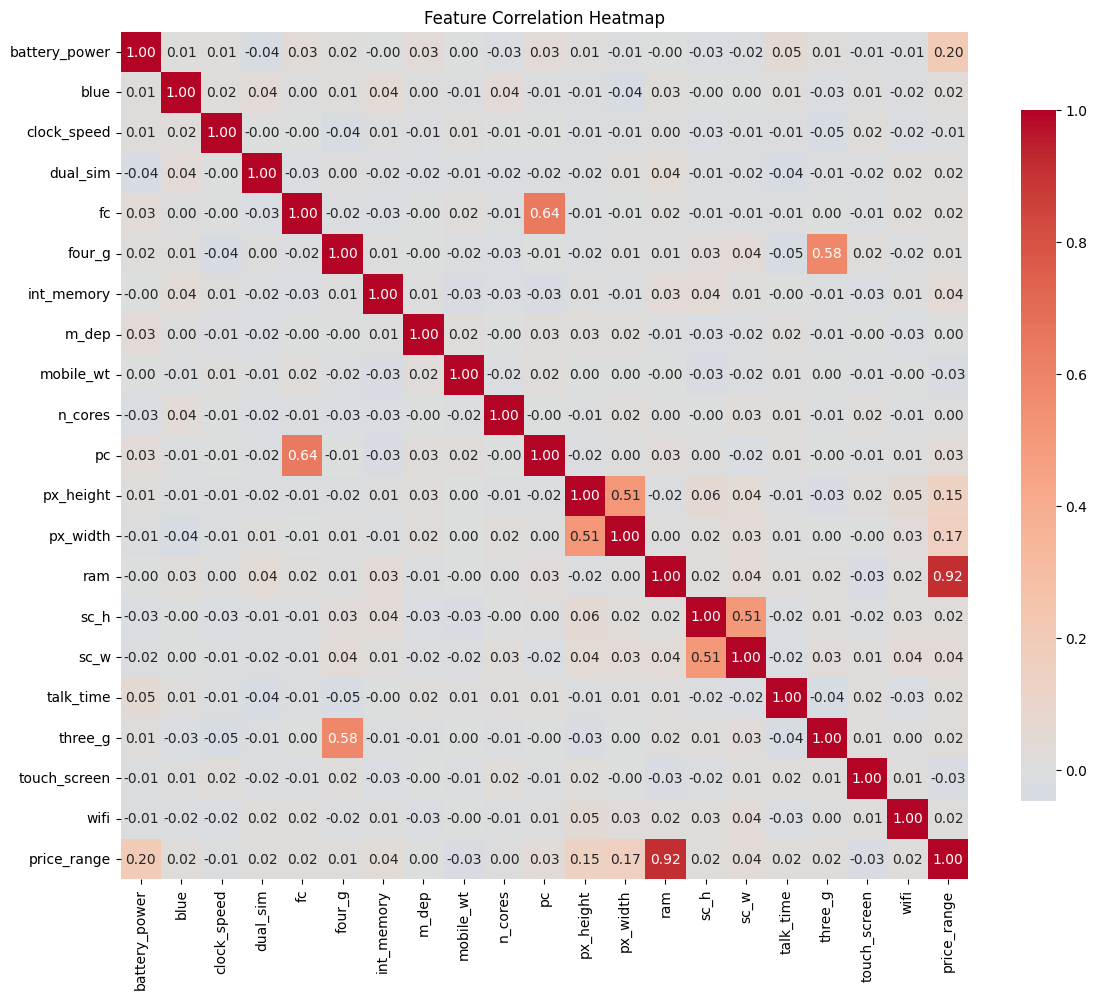

Top 10 features correlated with price_range:
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
Name: price_range, dtype: float64

Bottom 10 features correlated with price_range:
talk_time       0.021859
blue            0.020573
wifi            0.018785
dual_sim        0.017444
four_g          0.014772
n_cores         0.004399
m_dep           0.000853
clock_speed    -0.006606
mobile_wt      -0.030302
touch_screen   -0.030411
Name: price_range, dtype: float64

Selected 4 features with |correlation| > 0.1


In [3]:
def select_features_by_correlation(df, target_col, threshold=0.1):
    """
    Select features based on correlation with target variable
    """

    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', square=True, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    target_corr = corr_matrix[target_col].sort_values(ascending=False)

    print(f"Top 10 features correlated with {target_col}:")
    print(target_corr.head(10))

    print(f"\nBottom 10 features correlated with {target_col}:")
    print(target_corr.tail(10))

    selected_features = target_corr[abs(target_corr) > threshold].index.tolist()
    selected_features.remove(target_col)  

    print(f"\nSelected {len(selected_features)} features with |correlation| > {threshold}")

    return selected_features, corr_matrix

selected_features, corr_matrix = select_features_by_correlation(df, 'price_range', threshold=0.1)


### Extract the Most Relevant Features
Based on the correlation results, we filter the dataset to retain the strongest features (`ram`, `battery_power`, `px_width`, `px_height`) along with our target variable.

In [4]:
df_final =df.filter(items=['price_range','ram','battery_power','px_width','px_height'])
df_final

,price_range,ram,battery_power,px_width,px_height
0,1,2549,842,756,20
1,2,2631,1021,1988,905
2,2,2603,563,1716,1263
3,2,2769,615,1786,1216
4,1,1411,1821,1212,1208
...,...,...,...,...,...
1995,0,668,794,1890,1222
1996,2,2032,1965,1965,915
1997,3,3057,1911,1632,868
1998,0,869,1512,670,336


### Data Splitting
We separate our features (`x`) from the target variable (`y`). Then, we split the data into training (70%) and testing (30%) sets using `train_test_split` to allow unbiased evaluation of our model.

In [5]:
x = df_final
y = df_final['price_range']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

### Initialize and Train the Model
We instantiate the `LogisticRegression` classifier and fit it to our training data (`x_train`, `y_train`).

In [6]:
ls =LogisticRegression()
ls.fit(x_train,y_train)

c:\Users\Yousef_Osama\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Make Predictions
We use our trained logistic regression model to predict the price ranges on the testing set (`x_test`).

In [7]:
y_pred = ls.predict(x_test)

### Model Evaluation
We evaluate the performance of our Logistic Regression model using Accuracy, the Confusion Matrix, and the Classification Report.

In [8]:
# Calculate accuracy
acc = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {acc:.2f}%\n")

# Print the Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n")

# Print the Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 98.50%

Confusion Matrix:
[[151   0   0   0]
 [  0 146   0   0]
 [  0   0 146   2]
 [  0   0   7 148]]


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       151
           1       1.00      1.00      1.00       146
           2       0.95      0.99      0.97       148
           3       0.99      0.95      0.97       155

    accuracy                           0.98       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.98      0.99       600

